In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

# Exercise 12-1
- Author thinks the negative rentals problem can be alleviated via removing non-rainfall days
- Repeat the analysis and graph for this analysis but only select rows that have nonzero rainfall

In [14]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
data = pd.read_csv(url,sep=',',encoding='unicode_escape')
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [15]:
data.dtypes

Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

In [16]:
data["Date"] = pd.to_datetime(data["Date"], format='%d/%m/%Y')
data.dtypes

Date                         datetime64[us]
Rented Bike Count                     int64
Hour                                  int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                                 str
Holiday                                 str
Functioning Day                         str
dtype: object

<Axes: xlabel='Date', ylabel='Rented Bike Count'>

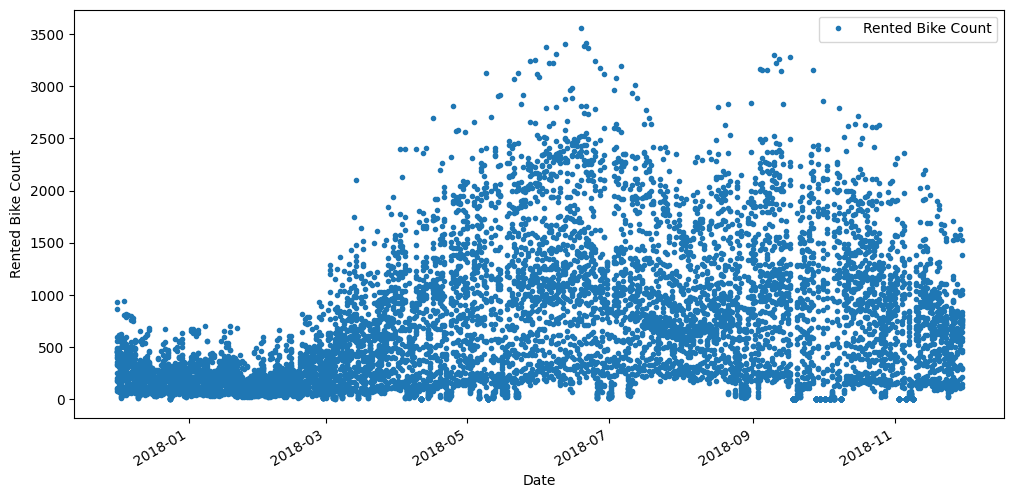

In [17]:
data.plot(x='Date',y='Rented Bike Count',marker='.',linestyle='none',
          figsize=(12,6),ylabel='Rented Bike Count')

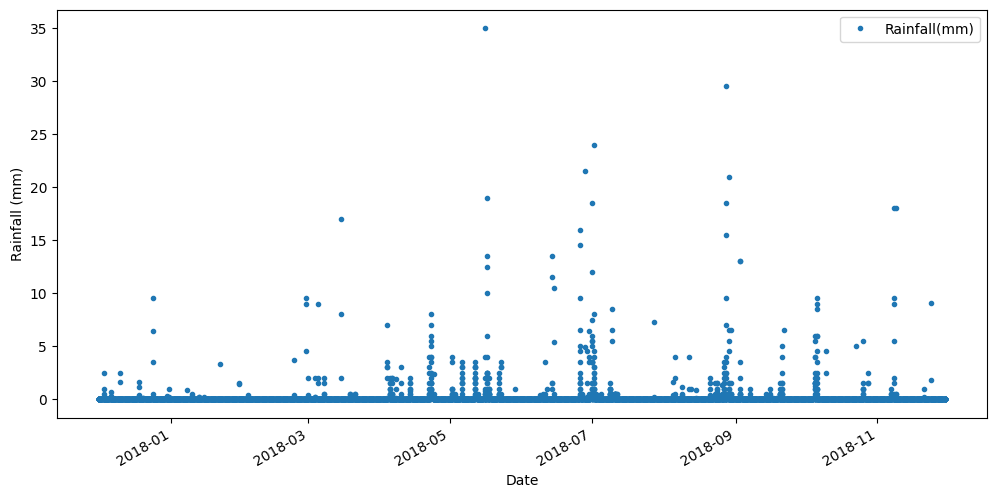

In [18]:
data.plot(x='Date',y='Rainfall(mm)',marker='.',linestyle='none',
          figsize=(12,6),ylabel='Rainfall (mm)');

In [20]:
# only using a few columns
columns2use = ['Rented Bike Count','Hour','Temperature(°C)','Rainfall(mm)']
colsshort = ['Bikes','Hour','Temp.','Rain'] # for axis labeleing

# re-compute the correlation matrix
R = data[columns2use].corr()
R

,Rented Bike Count,Hour,Temperature(°C),Rainfall(mm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.123074
Hour,0.410257,1.000000,0.124114,0.008715
Temperature(°C),0.538558,0.124114,1.000000,0.050282
Rainfall(mm),-0.123074,0.008715,0.050282,1.000000


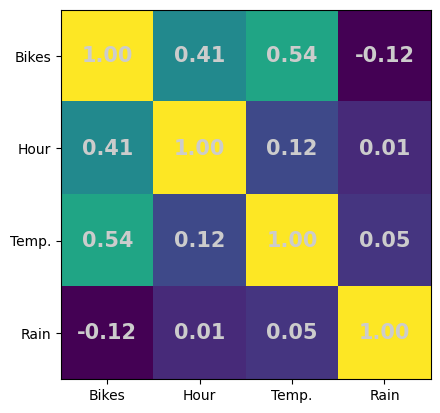

In [24]:
plt.imshow(R.values)
plt.xticks(range(4),labels=colsshort)
plt.yticks(range(4),labels=colsshort)
for (j,i),num in np.ndenumerate(R.values):
  plt.text(i,j,f'{num:.2f}',color=[.8,.8,.8],ha='center',va='center',fontweight='bold',fontsize=15)
plt.show()

In [ ]:
data.replace(['Spring','Summer', 'Autumn','Winter'],[1,1,0,0], inplace=True)

In [48]:
# select for only days with rainfall
data[data["Rainfall(mm)"] != 0.0][['Rainfall(mm)','Seasons']]

,Rainfall(mm),Seasons
51,0.5,0
54,1.0,0
57,2.5,0
78,0.1,0
120,0.1,0
...,...,...
8241,0.5,0
8520,0.2,0
8523,1.0,0
8601,9.1,0


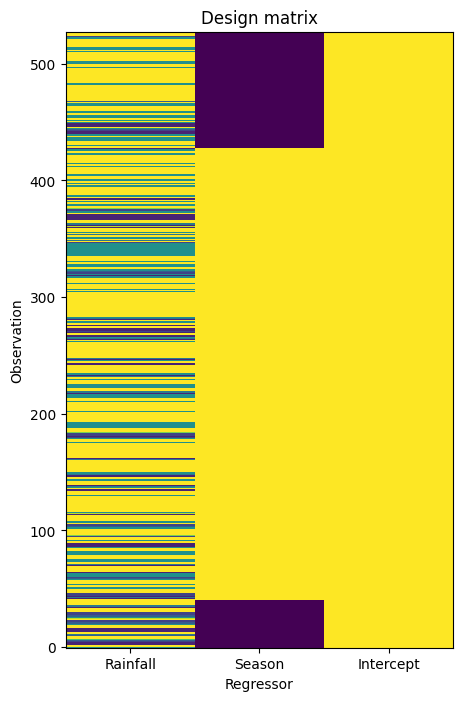

In [50]:
# Create a design matrix
desmat = data[data["Rainfall(mm)"] != 0.0][['Rainfall(mm)','Seasons']].to_numpy()

# add an intercept
desmat = np.append(desmat,np.ones((desmat.shape[0],1)),axis=1)
desmat = desmat.astype(float)

# extract DV
y = data[data["Rainfall(mm)"] != 0.0][['Rented Bike Count']].to_numpy()


# visualize the design matrix
plt.figure(figsize=(5,8))
plt.imshow(desmat,aspect='auto',vmin=0,vmax=1,origin='lower',interpolation='nearest')
plt.ylabel('Observation')
plt.xlabel('Regressor')
plt.title('Design matrix')
plt.xticks(range(3),labels=['Rainfall','Season','Intercept'])
plt.show()

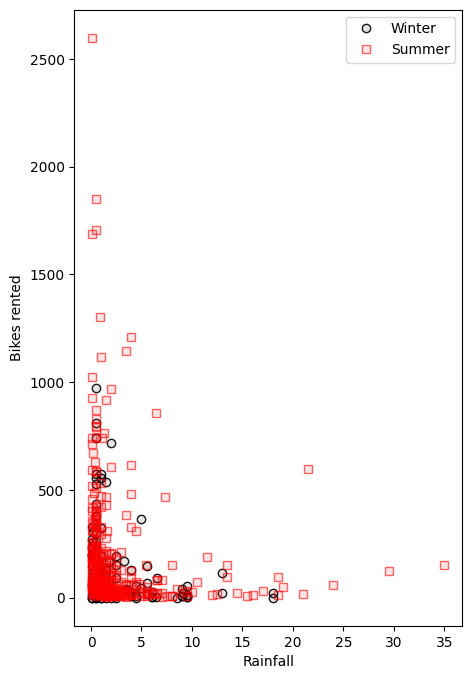

In [51]:
# plot the data
plt.figure(figsize=(5,8))

desmat[desmat[:,1]==0,0]
y[desmat[:,1]==0]

# separately for autumn/winter and spring/summer
plt.plot(desmat[desmat[:,1]==0,0],y[desmat[:,1]==0],'o',markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(desmat[desmat[:,1]==1,0],y[desmat[:,1]==1],'s',markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')

plt.xlabel('Rainfall')
plt.ylabel('Bikes rented')
plt.legend()
plt.show()

In [52]:
# run the regression
beta = np.linalg.lstsq(desmat,y,rcond=None)
beta[0]

array([[ -9.82999823],
       [ 48.42999142],
       [152.11692428]])

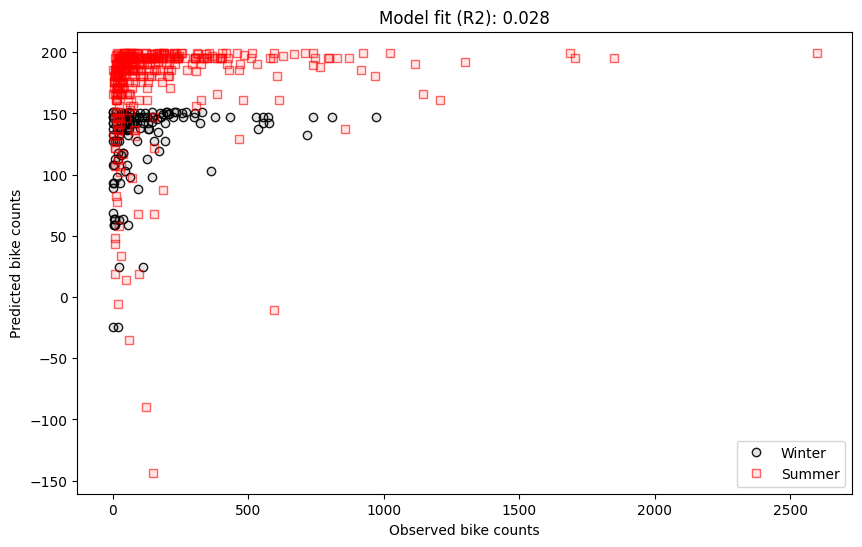

In [53]:
## plot some results.

# predicted data
yHat = desmat@beta[0]

# model fit to data (R^2)
modelfit = np.corrcoef(y.T,yHat.T)[0,1]**2


# and plot
plt.figure(figsize=(10,6))
plt.plot(y[desmat[:,1]==0],yHat[desmat[:,1]==0],'o',markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(y[desmat[:,1]==1],yHat[desmat[:,1]==1],'s',markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')
plt.legend()
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit (R2): {modelfit:.3f}')
plt.show()

The results did slightly improve but only by 1%. Our R2 value is now 0.028. We also did see a decrease in the amount of negative estimations.